In [1]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

Defaulting to user installation because normal site-packages is not writeable


Note: you may need to restart the kernel to use updated packages.


# 📊 Étape 4 : Visualisation Multidimensionnelle (Squelette Étudiant)

Cette étape correspond au quatrième chapitre du cours. L'objectif est de concevoir des représentations visuelles pour identifier des tendances et insights clés du dataset **Automobile** : évolution de la consommation par année, corrélations entre variables, et relations bivariées entre puissance et efficacité.

### 1. Préparation de l'environnement

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sys.path.append(os.path.abspath('..'))

print("Librairies de visualisation prêtes !")

Librairies de visualisation prêtes !


### 2. Chargement du dataset enrichi

In [3]:
df = pd.read_csv('../data/processed/cleaned_data_sample.csv')

# Recréation des features issues de l'EDA
df['power_to_weight'] = df['horsepower'] / df['weight']
df['mpg_category'] = pd.qcut(
    df['mpg'],
    q=3,
    labels=['faible', 'moyenne', 'élevée']
)

print(f"Shape : {df.shape}")
df.head()

Shape : (398, 10)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,power_to_weight,mpg_category
0,18.0,8,307.0,130.0,3504,12.0,70,2,0.037100,faible
1,15.0,8,350.0,165.0,3693,11.5,70,2,0.044679,faible
2,18.0,8,318.0,150.0,3436,11.0,70,2,0.043655,faible
3,16.0,8,304.0,150.0,3433,12.0,70,2,0.043694,faible
4,17.0,8,302.0,140.0,3449,10.5,70,2,0.040591,faible


### 3. Tracés et analyses graphiques

#### A. Évolution des tendances dans le temps

Évolution de la consommation moyenne (MPG) par année de modèle — permet d'observer le progrès des motorisations au fil du temps.

Graphique sauvegardé : ../data/processed/mpg_evolution.png


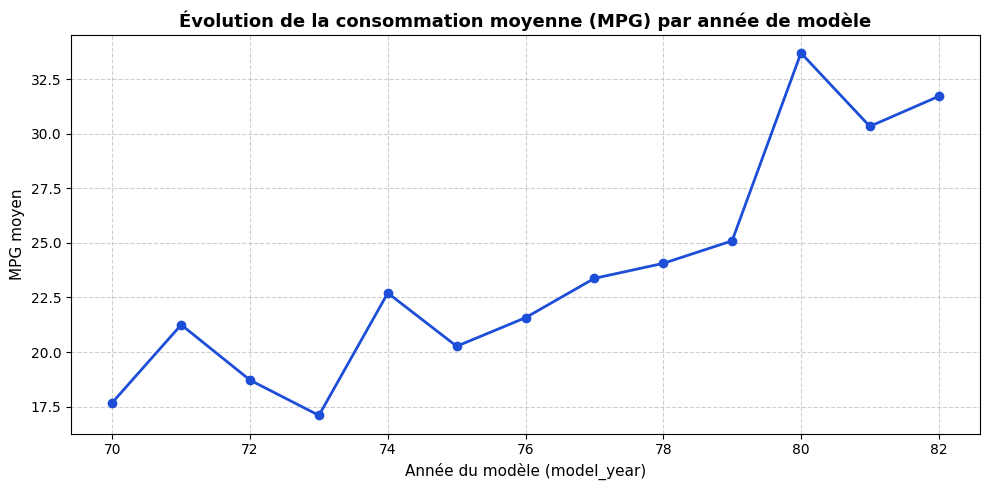

In [4]:
mpg_per_year = df.groupby('model_year')['mpg'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mpg_per_year.index, mpg_per_year.values,
        marker='o', linewidth=2, color='#1d4ed8', markersize=6)
ax.set_title("Évolution de la consommation moyenne (MPG) par année de modèle",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Année du modèle (model_year)", fontsize=11)
ax.set_ylabel("MPG moyen", fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, 'mpg_evolution.png'), dpi=120, bbox_inches='tight')
print("Graphique sauvegardé : ../data/processed/mpg_evolution.png")
plt.show()

#### B. Carte de chaleur des corrélations

Heatmap de la matrice de corrélation de Pearson sur l'ensemble des variables numériques, incluant la variable dérivée `power_to_weight`.

Graphique sauvegardé : ../data/processed/correlation_heatmap.png


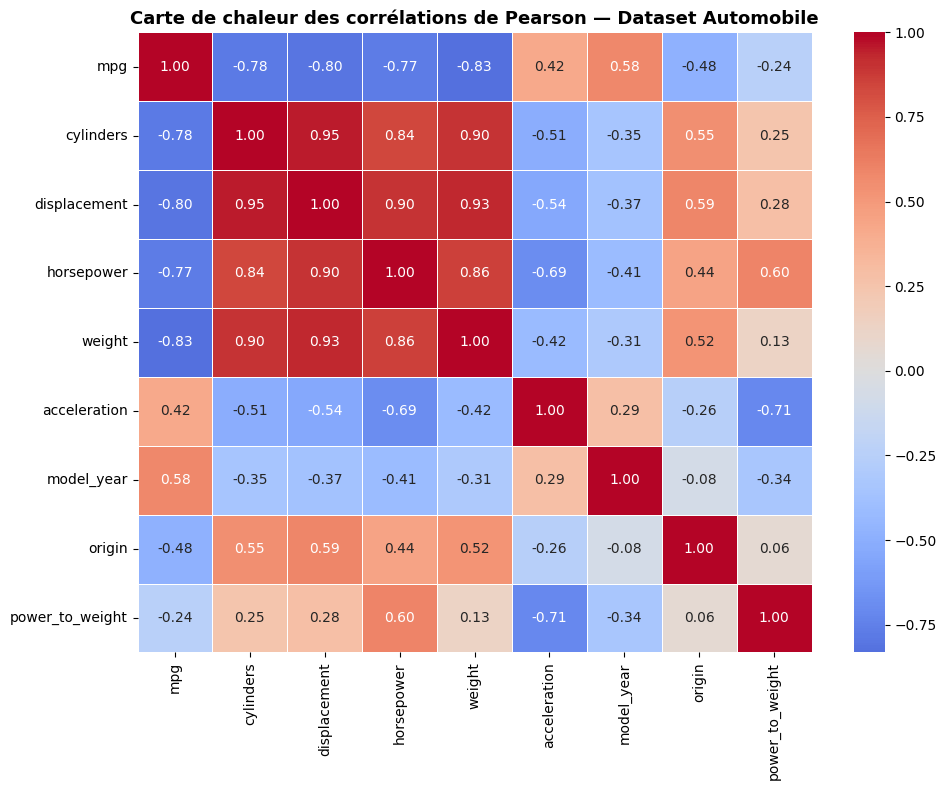

In [5]:
corr_cols = ['mpg', 'cylinders', 'displacement', 'horsepower',
             'weight', 'acceleration', 'model_year', 'origin', 'power_to_weight']
corr_matrix = df[corr_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Carte de chaleur des corrélations de Pearson — Dataset Automobile",
             fontsize=13, fontweight='bold')
plt.tight_layout()

fig.savefig(os.path.join(output_dir, 'correlation_heatmap.png'), dpi=120, bbox_inches='tight')
print("Graphique sauvegardé : ../data/processed/correlation_heatmap.png")
plt.show()

#### C. Nuage de points bivarié

Relation entre la puissance moteur (`horsepower`) et la consommation (`mpg`), colorée par origine géographique du véhicule (0=Europe, 1=Japon, 2=USA).

Graphique sauvegardé : ../data/processed/scatter_hp_mpg.png


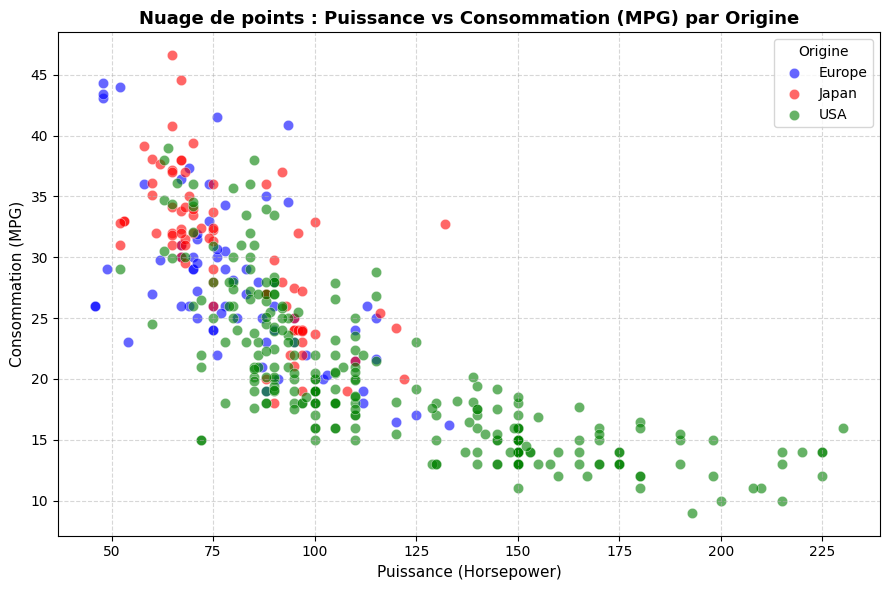

In [6]:
origin_config = {
    0: ('Europe', 'blue'),
    1: ('Japan',  'red'),
    2: ('USA',    'green')
}

fig, ax = plt.subplots(figsize=(9, 6))
for origin_code, (label, color) in origin_config.items():
    subset = df[df['origin'] == origin_code]
    ax.scatter(
        subset['horsepower'],
        subset['mpg'],
        label=label,
        color=color,
        alpha=0.6,
        edgecolors='white',
        linewidths=0.4,
        s=55
    )

ax.set_title("Nuage de points : Puissance vs Consommation (MPG) par Origine",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Puissance (Horsepower)", fontsize=11)
ax.set_ylabel("Consommation (MPG)", fontsize=11)
ax.legend(title='Origine', fontsize=10, title_fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

fig.savefig(os.path.join(output_dir, 'scatter_hp_mpg.png'), dpi=120, bbox_inches='tight')
print("Graphique sauvegardé : ../data/processed/scatter_hp_mpg.png")
plt.show()